## Carga de datos y librerias

In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

os.makedirs('img', exist_ok=True)

In [45]:
data_path = os.path.join('data', '2107_electrical_data.csv')
df = pd.read_csv(data_path)
print(df.shape)
df.info()

(632952, 120)
<class 'pandas.DataFrame'>
RangeIndex: 632952 entries, 0 to 632951
Columns: 120 entries, measured_on to inv_24_ac_power_inv_149698
dtypes: float64(119), str(1)
memory usage: 579.5 MB


In [46]:
df.head()

,measured_on,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
0,2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-11-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-11-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
df.describe()

,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,inv_02_ac_power_inv_149588,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
count,632586.000000,632586.000000,632586.000000,632586.000000,632586.000000,632586.000000,632586.000000,632586.000000,632586.000000,632586.000000,...,631224.000000,631224.000000,631224.000000,631224.000000,631224.000000,631224.000000,631224.000000,631224.000000,631224.000000,631224.000000
mean,9.856498,319.205209,7.454513,136.362110,6.363338,9.228654,316.131588,6.988613,135.249976,5.982282,...,10.028295,332.493139,7.700779,142.157008,6.577954,9.691090,327.085068,7.449268,139.982626,6.382338
std,15.343311,337.317409,11.367359,143.161743,9.933949,14.928043,336.273826,10.973514,143.443901,9.607771,...,15.605688,338.846880,11.595841,143.247243,10.158701,15.295462,338.176004,11.389543,143.089715,10.000710
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.029000,675.261000,12.696000,286.213000,10.763000,13.966000,672.873000,11.175000,287.051000,9.538000,...,16.707000,680.205000,13.384000,286.370000,11.432250,15.544250,679.236000,12.518000,286.016000,10.718000
max,52.348000,909.840000,36.363000,310.677000,30.096000,54.844000,1750.755000,36.103000,310.508000,30.088000,...,54.575000,913.080000,35.848000,310.822000,30.106000,55.051000,912.795000,36.066000,310.605000,30.089000


Tenemos 632,952 filas y 120 columnas. Los datos van de nov 2017 a nov 2023, medidos cada 5 minutos. Son 24 inversores solares, cada uno con dc_current, dc_voltage, ac_current, ac_voltage y ac_power.

## Comprension del problema

Estos datos vienen de una planta solar fotovoltaica con 24 inversores. Cada inversor convierte la corriente directa (DC) de los paneles en corriente alterna (AC) para inyectar a la red.

Lo que quiero hacer con este dataset es entender como se comportan los inversores, si todos producen parejo, detectar si hay inversores que se comporten raro y poder anticipar la produccion a futuro.

La variable objetivo que voy a usar para el modelo supervisado es ac_power, pero no la voy a predecir desde las otras variables electricas del mismo inversor porque eso seria redundante (la potencia se calcula directamente a partir de corriente y voltaje). En vez de eso voy a usar variables temporales como la hora y el mes para predecir cuanto deberia generar un inversor bajo condiciones normales. Si la prediccion dice 20 kW y en realidad genera 12, eso indica un problema.

## Exploracion de datos

In [48]:
# convertir fecha y sacar variables temporales
df['measured_on'] = pd.to_datetime(df['measured_on'])
df['hora'] = df['measured_on'].dt.hour
df['mes'] = df['measured_on'].dt.month
df['año'] = df['measured_on'].dt.year
df['dia_semana'] = df['measured_on'].dt.dayofweek
print('Rango:', df['measured_on'].min(), 'a', df['measured_on'].max())

Rango: 2017-11-01 00:00:00 a 2023-11-07 23:55:00


In [49]:
# revisar nulos
nulos = df.isnull().sum()
nulos_con_valores = nulos[nulos > 0]
print(f'Columnas con nulos: {len(nulos_con_valores)}')
print(f'Total de valores nulos: {df.isnull().sum().sum()}')
print()
print(nulos_con_valores.head(15))

Columnas con nulos: 114
Total de valores nulos: 183372

inv_01_dc_current_inv_149579     366
inv_01_dc_voltage_inv_149580     366
inv_01_ac_current_inv_149581     366
inv_01_ac_voltage_inv_149582     366
inv_01_ac_power_inv_149583       366
inv_02_dc_current_inv_149584     366
inv_02_dc_voltage_inv_149585     366
inv_02_ac_current_inv_149586     366
inv_02_ac_voltage_inv_149587     366
inv_02_ac_power_inv_149588       366
inv_04_dc_current_inv_149594    1728
inv_04_dc_voltage_inv_149595    1728
inv_04_ac_current_inv_149596    1728
inv_04_ac_voltage_inv_149597    1728
inv_04_ac_power_inv_149598      1728
dtype: int64


In [50]:
# columnas de potencia AC de cada inversor
power_cols = [c for c in df.columns if 'ac_power' in c]
print(f'Inversores con potencia AC: {len(power_cols)}')

Inversores con potencia AC: 24


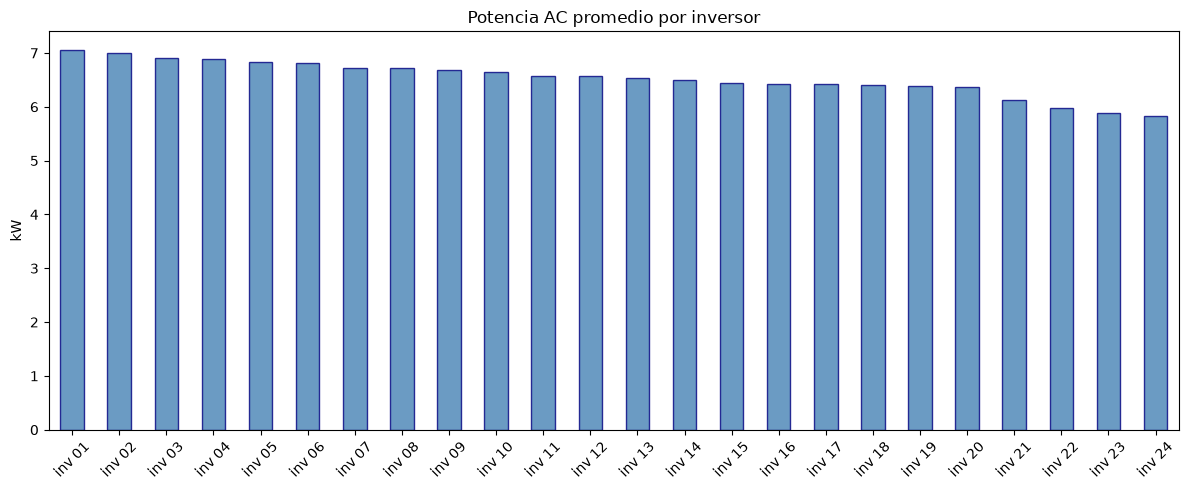

In [51]:
# potencia promedio de cada inversor
promedios = df[power_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
promedios.plot(kind='bar', ax=ax, color='steelblue', edgecolor='navy', alpha=0.8)
ax.set_title('Potencia AC promedio por inversor')
ax.set_ylabel('kW')
ax.set_xlabel('')
plt.xticks(range(len(promedios)), [f'inv {str(i+1).zfill(2)}' for i in range(24)], rotation=45)
plt.tight_layout()
plt.savefig('img/potencia_promedio_inversores.png', dpi=150, bbox_inches='tight')
plt.show()

Los inversores se comportan de manera bastante similar entre si, con diferencias minimas en la produccion promedio. Esto es esperable porque todos estan en la misma planta recibiendo la misma radiacion.

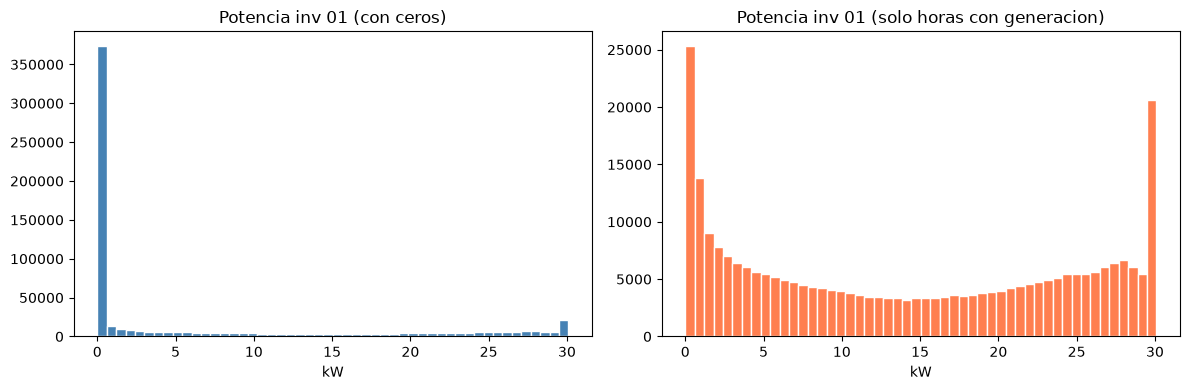

Registros totales: 632952
Con generacion: 284011 (44.9%)


In [52]:
# distribucion de potencia del inv 01
inv01_power = df['inv_01_ac_power_inv_149583']
inv01_dia = inv01_power[inv01_power > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(inv01_power, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Potencia inv 01 (con ceros)')
axes[0].set_xlabel('kW')

axes[1].hist(inv01_dia, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Potencia inv 01 (solo horas con generacion)')
axes[1].set_xlabel('kW')
plt.tight_layout()
plt.savefig('img/distribucion_potencia_inv01.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Registros totales: {len(inv01_power)}')
print(f'Con generacion: {len(inv01_dia)} ({len(inv01_dia)/len(inv01_power)*100:.1f}%)')

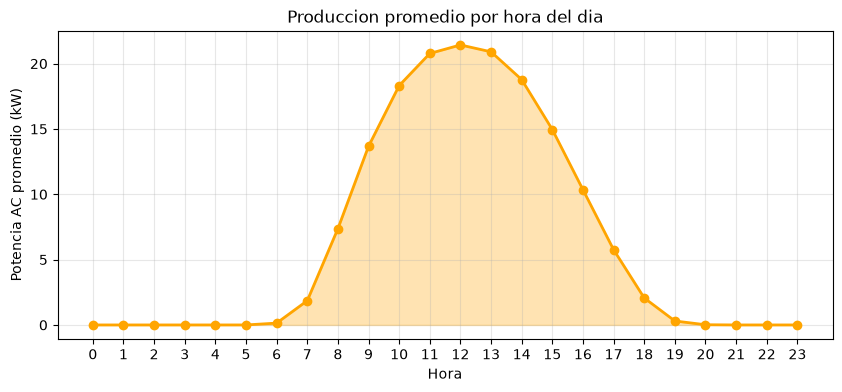

In [53]:
# patron por hora del dia
potencia_hora = df.groupby('hora')[power_cols].mean().mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(potencia_hora.index, potencia_hora.values, 'o-', color='orange', linewidth=2)
plt.fill_between(potencia_hora.index, potencia_hora.values, alpha=0.3, color='orange')
plt.title('Produccion promedio por hora del dia')
plt.xlabel('Hora')
plt.ylabel('Potencia AC promedio (kW)')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.savefig('img/patron_horario.png', dpi=150, bbox_inches='tight')
plt.show()

Tiene forma de campana como se espera de paneles solares. La produccion pico esta entre las 10am y 2pm, y en la noche es cero.

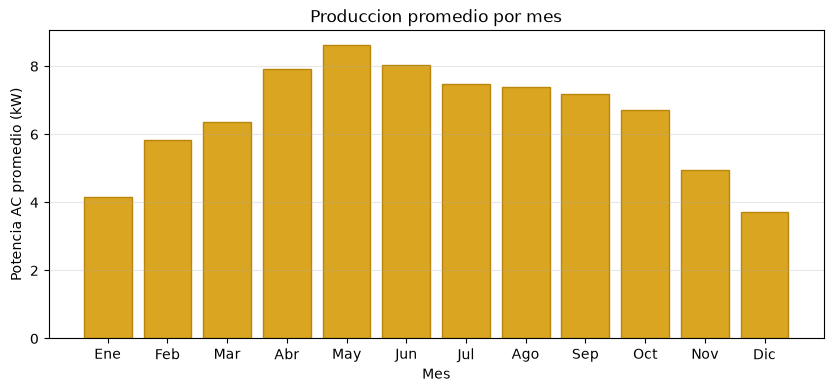

In [54]:
# patron mensual
potencia_mes = df.groupby('mes')[power_cols].mean().mean(axis=1)

plt.figure(figsize=(10, 4))
plt.bar(potencia_mes.index, potencia_mes.values, color='goldenrod', edgecolor='darkgoldenrod')
plt.title('Produccion promedio por mes')
plt.xlabel('Mes')
plt.ylabel('Potencia AC promedio (kW)')
plt.xticks(range(1, 13), ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.grid(axis='y', alpha=0.3)
plt.savefig('img/patron_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

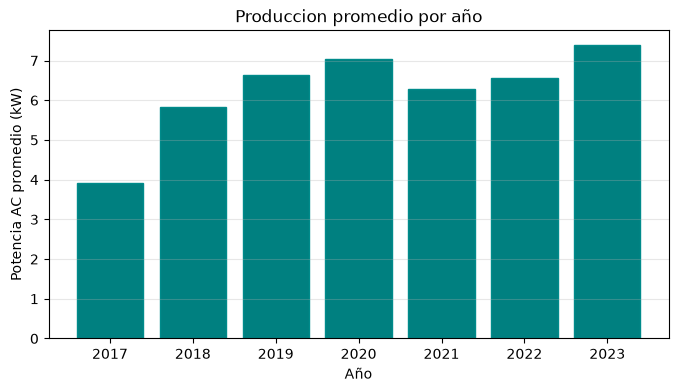

año
2017    3.921615
2018    5.836260
2019    6.638166
2020    7.046871
2021    6.285086
2022    6.556293
2023    7.387360
dtype: float64


In [55]:
# produccion por año
potencia_año = df.groupby('año')[power_cols].mean().mean(axis=1)

plt.figure(figsize=(8, 4))
plt.bar(potencia_año.index, potencia_año.values, color='teal', edgecolor='darkcyan')
plt.title('Produccion promedio por año')
plt.xlabel('Año')
plt.ylabel('Potencia AC promedio (kW)')
plt.grid(axis='y', alpha=0.3)
plt.savefig('img/patron_anual.png', dpi=150, bbox_inches='tight')
plt.show()
print(potencia_año)

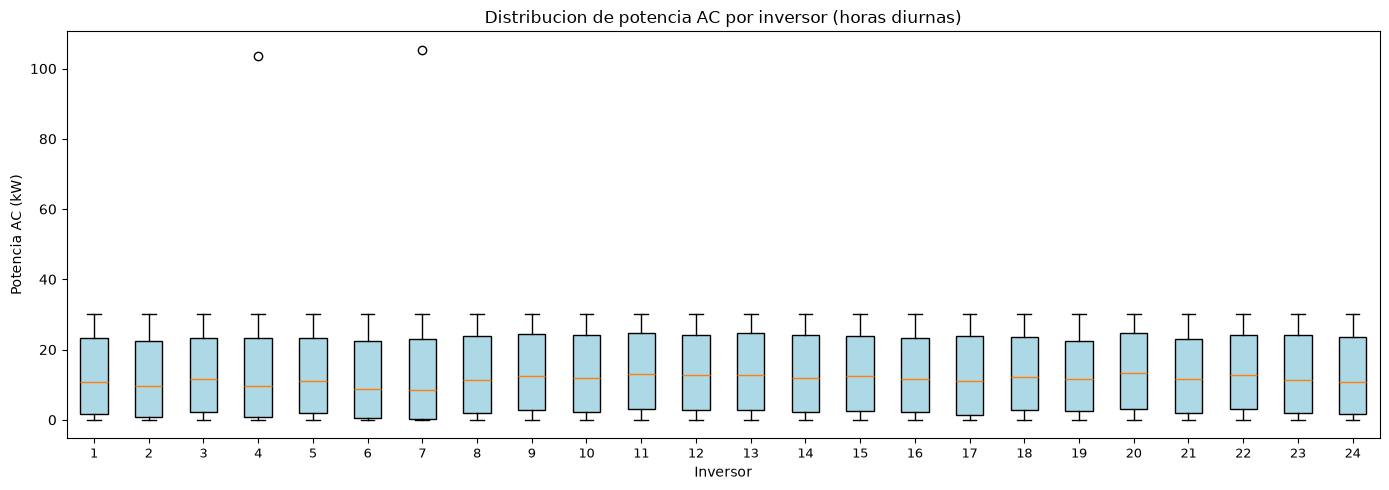

In [56]:
# boxplots de potencia por inversor (solo horas diurnas)
df_dia = df[df['hora'].between(7, 18)].copy()

fig, ax = plt.subplots(figsize=(14, 5))
datos_box = [df_dia[c].dropna().values for c in power_cols]
bp = ax.boxplot(datos_box, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_xticklabels([f'{i+1}' for i in range(24)], fontsize=9)
ax.set_xlabel('Inversor')
ax.set_ylabel('Potencia AC (kW)')
ax.set_title('Distribucion de potencia AC por inversor (horas diurnas)')
plt.tight_layout()
plt.savefig('img/boxplot_inversores.png', dpi=150, bbox_inches='tight')
plt.show()

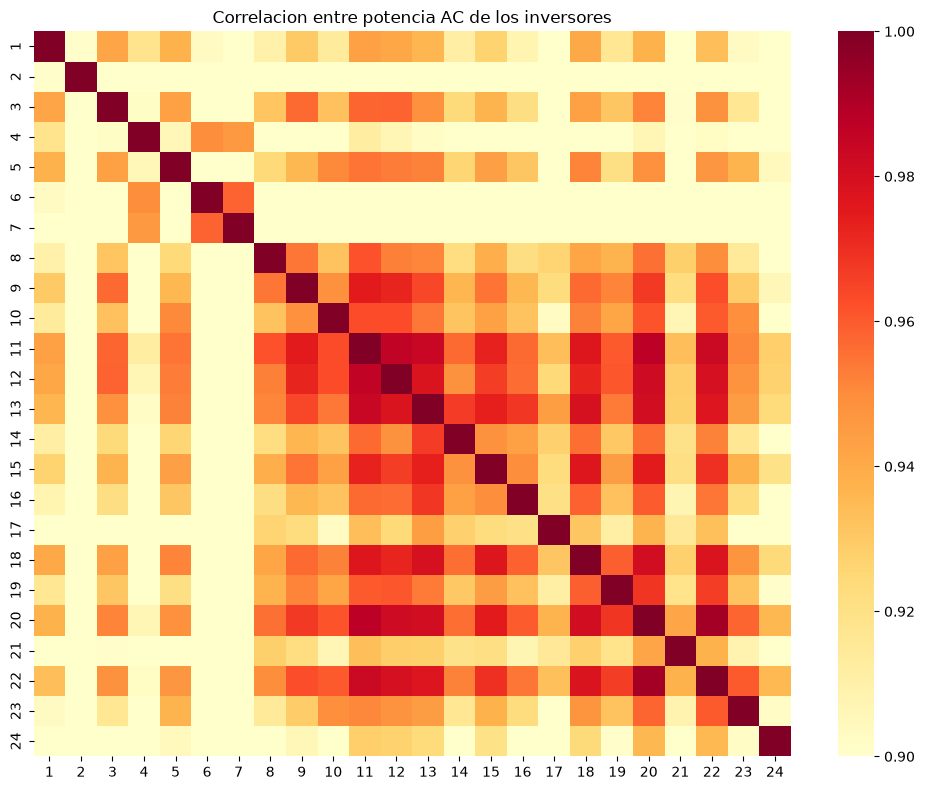

Correlacion minima: 0.8158
Correlacion promedio: 0.9188


In [57]:
# correlacion entre inversores (potencia AC)
corr_power = df[power_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_power, cmap='YlOrRd', vmin=0.9, vmax=1, 
            xticklabels=[f'{i+1}' for i in range(24)],
            yticklabels=[f'{i+1}' for i in range(24)],
            annot=False)
plt.title('Correlacion entre potencia AC de los inversores')
plt.tight_layout()
plt.savefig('img/correlacion_inversores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlacion minima: {corr_power.min().min():.4f}')
print(f'Correlacion promedio: {corr_power.values[np.triu_indices(24, k=1)].mean():.4f}')

Las correlaciones son muy altas entre todos los inversores. Tiene sentido porque todos reciben la misma radiacion solar. Si alguno tuviera correlacion baja con los demas seria sospechoso de tener algun problema.

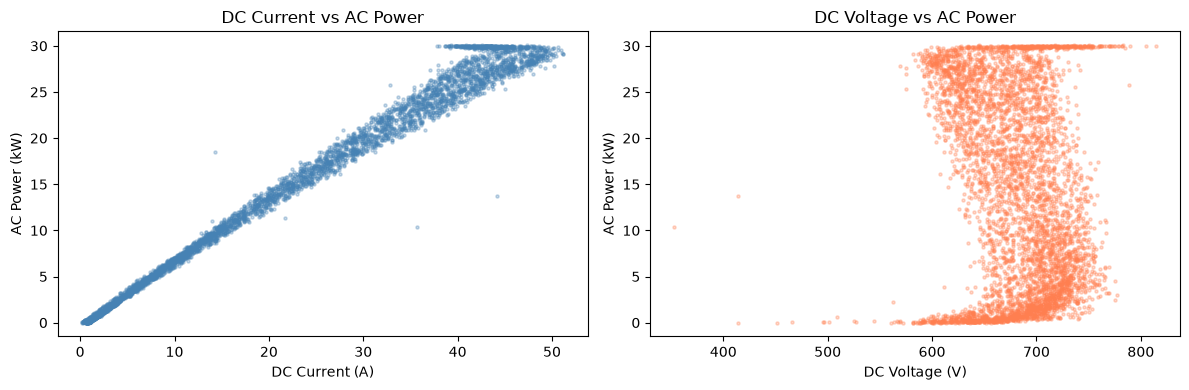

In [58]:
# relacion entre variables del inv 01
muestra = df[df['inv_01_ac_power_inv_149583'] > 0].sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(muestra['inv_01_dc_current_inv_149579'], 
                muestra['inv_01_ac_power_inv_149583'],
                alpha=0.3, s=5, color='steelblue')
axes[0].set_xlabel('DC Current (A)')
axes[0].set_ylabel('AC Power (kW)')
axes[0].set_title('DC Current vs AC Power')

axes[1].scatter(muestra['inv_01_dc_voltage_inv_149580'], 
                muestra['inv_01_ac_power_inv_149583'],
                alpha=0.3, s=5, color='coral')
axes[1].set_xlabel('DC Voltage (V)')
axes[1].set_ylabel('AC Power (kW)')
axes[1].set_title('DC Voltage vs AC Power')

plt.tight_layout()
plt.savefig('img/dc_current_vs_ac_power.png', dpi=150, bbox_inches='tight')
plt.show()

La corriente DC tiene una relacion casi lineal con la potencia AC. El voltaje DC en cambio se mantiene en un rango y no tiene relacion directa tan clara con la potencia.

## Preparacion de datos

In [59]:
# nulos
print(f'Total nulos: {df.isnull().sum().sum()}')
print(f'Columnas con nulos: {(df.isnull().sum() > 0).sum()} de {len(df.columns)}')

Total nulos: 183372
Columnas con nulos: 114 de 124


In [60]:
# rellenar nulos con forward fill y luego con 0
df_clean = df.copy()
cols_numericas = df_clean.select_dtypes(include=[np.number]).columns
df_clean[cols_numericas] = df_clean[cols_numericas].ffill().fillna(0)

print(f'Nulos despues de limpieza: {df_clean.isnull().sum().sum()}')

Nulos despues de limpieza: 0


In [61]:
# verificar duplicados
dupes = df_clean.duplicated(subset=['measured_on']).sum()
print(f'Filas con fecha duplicada: {dupes}')

Filas con fecha duplicada: 0


No habia duplicados. Los nulos se llenaron con forward fill para mantener la continuidad de la serie temporal, y lo que quedo se puso en 0 (corresponde a horas nocturnas sin generacion).

In [62]:
# el inv 05 no tiene dc_voltage
inv05_cols = [c for c in df_clean.columns if 'inv_05' in c]
print('Columnas del inv 05:', inv05_cols)

Columnas del inv 05: ['inv_05_dc_current_inv_149599', 'inv_05_ac_current_inv_149601', 'inv_05_ac_voltage_inv_149602', 'inv_05_ac_power_inv_149603']


In [63]:
# crear potencia total de la planta
df_clean['potencia_total'] = df_clean[power_cols].sum(axis=1)

# df solo con horas de generacion
df_gen = df_clean[df_clean['potencia_total'] > 0].copy()
print(f'Registros con generacion: {len(df_gen)} ({len(df_gen)/len(df_clean)*100:.1f}%)')

Registros con generacion: 309308 (48.9%)


---
## Aprendizaje supervisado

El objetivo es predecir la potencia AC del inversor 01 usando variables temporales (hora y mes). No uso las variables electricas del propio inversor como features porque seria redundante, la potencia AC se calcula directamente a partir de corriente y voltaje. En cambio, predecir desde el tiempo tiene valor practico: nos dice cuanto deberia generar el inversor en condiciones normales segun la epoca del año y la hora del dia.

In [64]:
# preparar features y target
target = 'inv_01_ac_power_inv_149583'

model_df = df_gen[['hora', 'mes', target]].dropna()
print(f'Registros para modelar: {len(model_df)}')

X = model_df[['hora', 'mes']]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Registros para modelar: 309308
Train: 247446, Test: 61862


In [65]:
# revisar VIF de nuestras features
print('=== VIF ===')
for col in X.columns:
    otros = [c for c in X.columns if c != col]
    lr_vif = LinearRegression().fit(X[otros], X[col])
    r2_vif = lr_vif.score(X[otros], X[col])
    vif = 1 / (1 - r2_vif) if r2_vif < 1 else float('inf')
    print(f'  {col}: VIF = {vif:.2f}')
print('No hay multicolinealidad entre las features')

=== VIF ===
  hora: VIF = 1.00
  mes: VIF = 1.00
No hay multicolinealidad entre las features


In [66]:
# escalar
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [67]:
# modelo 1: regresion lineal
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
pred_lr_train = lr.predict(X_train_sc)
pred_lr_test = lr.predict(X_test_sc)

r2_lr_train = r2_score(y_train, pred_lr_train)
r2_lr_test = r2_score(y_test, pred_lr_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr_test))
mae_lr = mean_absolute_error(y_test, pred_lr_test)

print('--- Regresion Lineal ---')
print(f'R2 train: {r2_lr_train:.4f}')
print(f'R2 test:  {r2_lr_test:.4f}')
print(f'RMSE:     {rmse_lr:.4f}')
print(f'MAE:      {mae_lr:.4f}')

if r2_lr_train - r2_lr_test > 0.05:
    print('** Hay indicios de overfitting **')
else:
    print('No hay overfitting, los R2 estan cerca')

--- Regresion Lineal ---
R2 train: 0.0065
R2 test:  0.0061
RMSE:     10.6956
MAE:      9.6870
No hay overfitting, los R2 estan cerca


In [68]:
# modelo 2: random forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
pred_rf_train = rf.predict(X_train_sc)
pred_rf_test = rf.predict(X_test_sc)

r2_rf_train = r2_score(y_train, pred_rf_train)
r2_rf_test = r2_score(y_test, pred_rf_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf_test))
mae_rf = mean_absolute_error(y_test, pred_rf_test)

print('--- Random Forest ---')
print(f'R2 train: {r2_rf_train:.4f}')
print(f'R2 test:  {r2_rf_test:.4f}')
print(f'RMSE:     {rmse_rf:.4f}')
print(f'MAE:      {mae_rf:.4f}')

if r2_rf_train - r2_rf_test > 0.05:
    print('** Hay indicios de overfitting **')
else:
    print('No hay overfitting, los R2 estan cerca')

--- Random Forest ---
R2 train: 0.5946
R2 test:  0.5915
RMSE:     6.8567
MAE:      4.8536
No hay overfitting, los R2 estan cerca


In [69]:
# comparacion
print('=== Comparacion ===')
print(f'{"Metrica":<12} {"Reg. Lineal":>12} {"Random Forest":>14}')
print(f'{"R2 train":<12} {r2_lr_train:>12.4f} {r2_rf_train:>14.4f}')
print(f'{"R2 test":<12} {r2_lr_test:>12.4f} {r2_rf_test:>14.4f}')
print(f'{"RMSE":<12} {rmse_lr:>12.4f} {rmse_rf:>14.4f}')
print(f'{"MAE":<12} {mae_lr:>12.4f} {mae_rf:>14.4f}')

=== Comparacion ===
Metrica       Reg. Lineal  Random Forest
R2 train           0.0065         0.5946
R2 test            0.0061         0.5915
RMSE              10.6956         6.8567
MAE                9.6870         4.8536


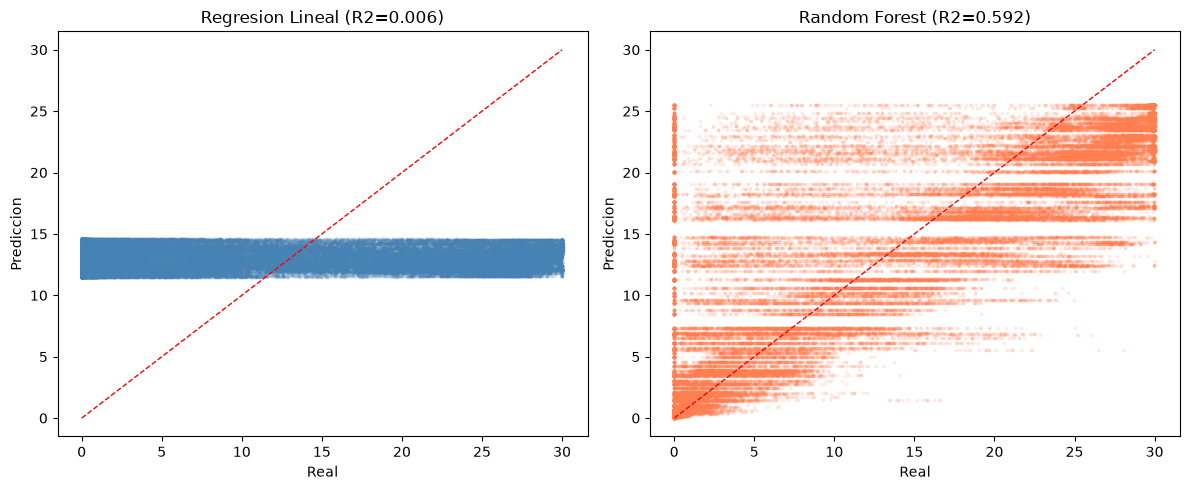

In [70]:
# grafica de prediccion vs real
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, pred_lr_test, alpha=0.1, s=3, color='steelblue')
axes[0].plot([0, 30], [0, 30], 'r--', linewidth=1)
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Prediccion')
axes[0].set_title(f'Regresion Lineal (R2={r2_lr_test:.3f})')

axes[1].scatter(y_test, pred_rf_test, alpha=0.1, s=3, color='coral')
axes[1].plot([0, 30], [0, 30], 'r--', linewidth=1)
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Prediccion')
axes[1].set_title(f'Random Forest (R2={r2_rf_test:.3f})')

plt.tight_layout()
plt.savefig('img/prediccion_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

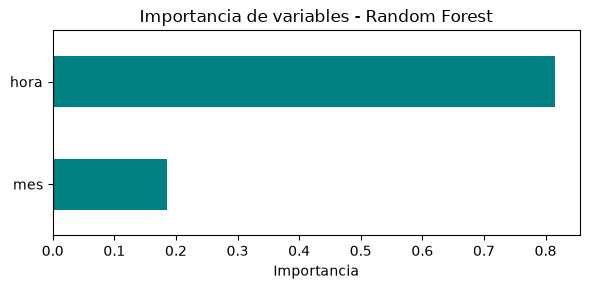

In [71]:
# importancia de variables
importancias = pd.Series(rf.feature_importances_, index=['hora', 'mes'])
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(6, 3))
importancias.plot(kind='barh', color='teal')
plt.title('Importancia de variables - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('img/importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
# exportar modelo y scaler
joblib.dump(rf, 'modelo_rf_inv01.pkl')
joblib.dump(scaler, 'scaler_inv01.pkl')
print('Modelo y scaler guardados')

Modelo y scaler guardados


El R2 no va a ser tan alto como si usaramos variables electricas, pero eso es correcto. Predecir desde el tiempo captura el patron promedio de generacion. La variabilidad que no se captura corresponde al clima del dia (nublado vs soleado), que no tenemos en este dataset.

---
## Aprendizaje no supervisado

Voy a agrupar los inversores segun su perfil de generacion por hora para ver si hay grupos con comportamiento distinto. Tambien hago PCA para visualizar y deteccion de anomalias en la produccion diaria.

In [73]:
# perfil de generacion por hora para cada inversor
perfiles = pd.DataFrame()
for i in range(1, 25):
    inv = str(i).zfill(2)
    col = [c for c in power_cols if f'inv_{inv}_' in c][0]
    perfil = df_clean.groupby('hora')[col].mean()
    perfiles[f'inv {inv}'] = perfil

perfiles.head()

,inv 01,inv 02,inv 03,inv 04,inv 05,inv 06,inv 07,inv 08,inv 09,inv 10,...,inv 15,inv 16,inv 17,inv 18,inv 19,inv 20,inv 21,inv 22,inv 23,inv 24
hora,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


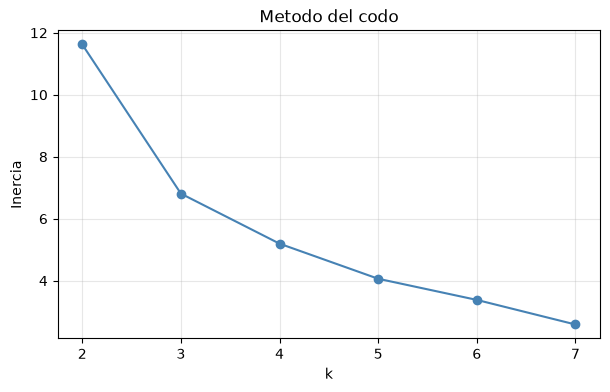

In [74]:
# normalizar y hacer clustering
scaler_km = MinMaxScaler()
perfiles_norm = pd.DataFrame(
    scaler_km.fit_transform(perfiles.T),
    index=perfiles.columns,
    columns=perfiles.index
)

# metodo del codo
inercias = []
rango_k = range(2, 8)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(perfiles_norm)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(rango_k), inercias, 'o-', color='steelblue')
plt.xlabel('k')
plt.ylabel('Inercia')
plt.title('Metodo del codo')
plt.grid(alpha=0.3)
plt.savefig('img/metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:
# usar k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km.fit_predict(perfiles_norm)

resultado_clusters = pd.DataFrame({
    'inversor': perfiles.columns,
    'cluster': clusters
})
print(resultado_clusters.sort_values('cluster').to_string(index=False))

sil = silhouette_score(perfiles_norm, clusters)
print(f'\nSilhouette Score: {sil:.4f}')

inversor  cluster
  inv 13        0
  inv 12        0
  inv 11        0
  inv 15        0
  inv 09        0
  inv 22        0
  inv 20        0
  inv 18        0
  inv 05        1
  inv 10        1
  inv 14        1
  inv 16        1
  inv 17        1
  inv 01        1
  inv 08        1
  inv 03        1
  inv 19        1
  inv 21        1
  inv 23        1
  inv 24        1
  inv 04        2
  inv 02        2
  inv 06        2
  inv 07        2

Silhouette Score: 0.3897


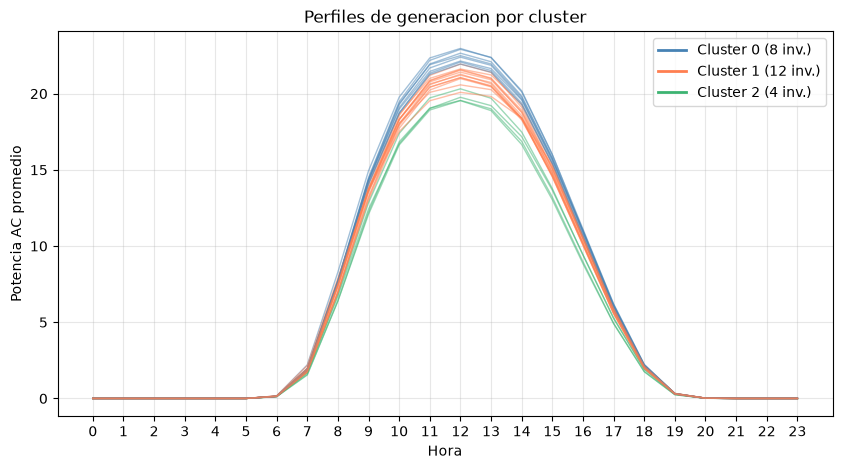

In [76]:
# graficar perfiles por cluster
colores_cluster = ['steelblue', 'coral', 'mediumseagreen']
fig, ax = plt.subplots(figsize=(10, 5))

for idx, row in resultado_clusters.iterrows():
    inv = row['inversor']
    cl = row['cluster']
    ax.plot(perfiles.index, perfiles[inv].values, 
            color=colores_cluster[cl], alpha=0.5, linewidth=1)

for cl in range(3):
    n = (resultado_clusters['cluster'] == cl).sum()
    ax.plot([], [], color=colores_cluster[cl], linewidth=2, label=f'Cluster {cl} ({n} inv.)')

ax.set_xlabel('Hora')
ax.set_ylabel('Potencia AC promedio')
ax.set_title('Perfiles de generacion por cluster')
ax.legend()
ax.set_xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.savefig('img/perfiles_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

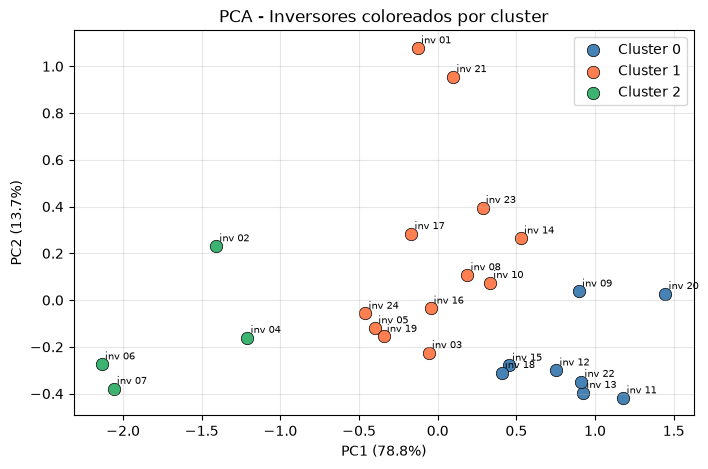

In [77]:
# PCA para visualizar en 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(perfiles_norm)

plt.figure(figsize=(8, 5))
for cl in range(3):
    mask = clusters == cl
    plt.scatter(coords[mask, 0], coords[mask, 1], 
                c=colores_cluster[cl], s=80, edgecolors='black', linewidth=0.5,
                label=f'Cluster {cl}')
    for j in np.where(mask)[0]:
        plt.annotate(resultado_clusters.iloc[j]['inversor'], 
                     (coords[j, 0]+0.02, coords[j, 1]+0.02), fontsize=7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA - Inversores coloreados por cluster')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('img/pca_inversores.png', dpi=150, bbox_inches='tight')
plt.show()

El PCA y el clustering muestran que la mayoria de inversores se comportan igual, con algunos que se separan ligeramente. Esto sirve como linea base: si un inversor empieza a alejarse de su grupo con el tiempo, puede indicar degradacion.

Dias totales: 2198
Dias anomalos: 0


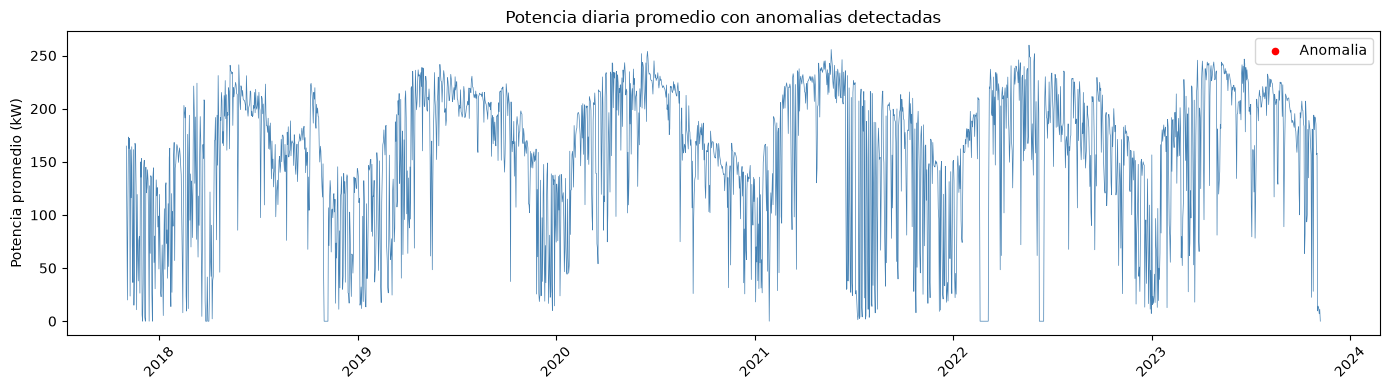

In [78]:
# deteccion de anomalias en la produccion diaria
potencia_diaria = df_clean.groupby(df_clean['measured_on'].dt.date)['potencia_total'].mean()
potencia_diaria = potencia_diaria.to_frame()
potencia_diaria.columns = ['pot_media']

# z-score
pot_mean = potencia_diaria['pot_media'].mean()
pot_std = potencia_diaria['pot_media'].std()
potencia_diaria['z_score'] = (potencia_diaria['pot_media'] - pot_mean) / pot_std
potencia_diaria['anomalia'] = potencia_diaria['z_score'].abs() > 2.5

print(f'Dias totales: {len(potencia_diaria)}')
print(f'Dias anomalos: {potencia_diaria["anomalia"].sum()}')

plt.figure(figsize=(14, 4))
plt.plot(potencia_diaria.index, potencia_diaria['pot_media'], linewidth=0.5, color='steelblue')
anomalos = potencia_diaria[potencia_diaria['anomalia']]
plt.scatter(anomalos.index, anomalos['pot_media'], color='red', s=20, zorder=5, label='Anomalia')
plt.title('Potencia diaria promedio con anomalias detectadas')
plt.ylabel('Potencia promedio (kW)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('img/anomalias_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

La deteccion anterior es basica porque solo ve si la produccion total es baja. El problema es que un dia nublado baja la produccion de todos los inversores y eso no es una falla. Para mejorar esto vamos a comparar cada inversor contra el promedio de los demas en cada momento. Si uno produce mucho menos que los otros al mismo tiempo, ahi si hay un problema real.

In [79]:
# calcular el ratio de cada inversor vs el promedio de los demas
# esto nos permite separar clima (afecta a todos) de fallas (afecta a uno)
df_diurno = df_clean[df_clean['hora'].between(8, 17)].copy()

ratios = pd.DataFrame()
ratios['measured_on'] = df_diurno['measured_on']

for i in range(1, 25):
    inv = str(i).zfill(2)
    # usar inv_XX_ con guion bajo al final para no matchear IDs numericos
    col_actual = [c for c in power_cols if f'inv_{inv}_' in c][0]
    otros = [c for c in power_cols if f'inv_{inv}_' not in c]
    
    media_otros = df_diurno[otros].mean(axis=1)
    # umbral mas alto para evitar divisiones por numeros muy chicos
    mask = media_otros > 2.0
    ratio = pd.Series(np.nan, index=df_diurno.index)
    ratio[mask] = df_diurno.loc[mask, col_actual] / media_otros[mask]
    ratios[f'ratio_inv_{inv}'] = ratio

print('Ratio promedio por inversor (1.0 = igual al resto):')
ratio_cols = [c for c in ratios.columns if 'ratio' in c]
print(ratios[ratio_cols].mean().sort_values().to_string())

Ratio promedio por inversor (1.0 = igual al resto):
ratio_inv_06    0.886058
ratio_inv_07    0.892009
ratio_inv_04    0.934625
ratio_inv_01    0.959569
ratio_inv_02    0.961281
ratio_inv_05    0.971077
ratio_inv_17    0.984681
ratio_inv_24    0.985746
ratio_inv_19    0.986051
ratio_inv_08    0.997672
ratio_inv_03    0.999896
ratio_inv_23    1.001558
ratio_inv_21    1.001946
ratio_inv_16    1.003420
ratio_inv_10    1.021124
ratio_inv_14    1.025643
ratio_inv_18    1.026387
ratio_inv_15    1.029878
ratio_inv_12    1.049084
ratio_inv_09    1.053222
ratio_inv_13    1.056587
ratio_inv_22    1.059369
ratio_inv_11    1.075997
ratio_inv_20    1.088906


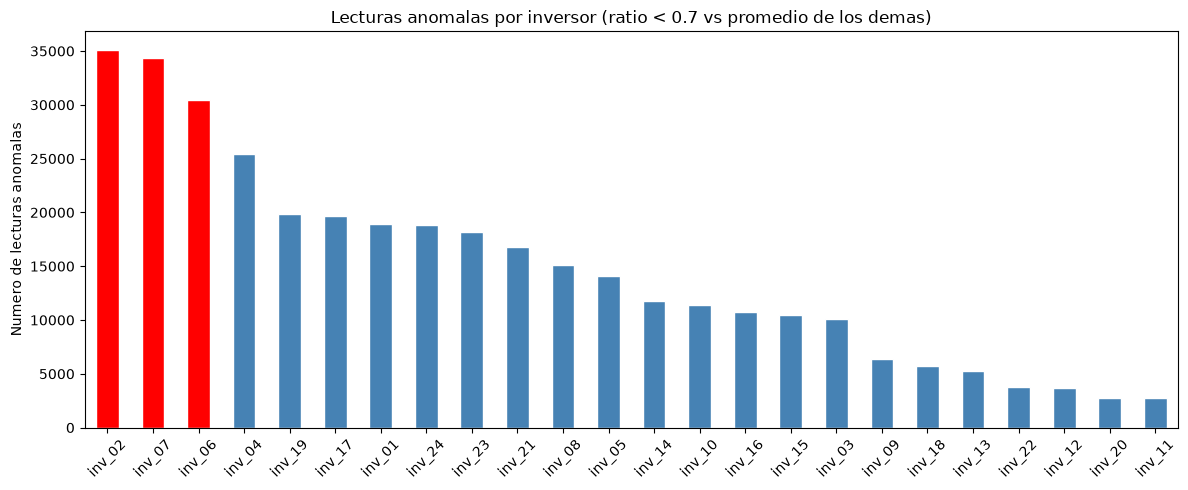


Inversores con mas anomalias (posibles problemas):
inv_02    35077
inv_07    34365
inv_06    30492
inv_04    25422
inv_19    19887


In [80]:
# detectar momentos donde un inversor rinde mucho menos que los demas
# si el ratio es menor a 0.7 significa que produce 30% menos que el promedio
umbral = 0.7
anomalias_por_inv = {}

for col in ratio_cols:
    inv_name = col.replace('ratio_', '')
    n_anomalias = (ratios[col] < umbral).sum()
    anomalias_por_inv[inv_name] = n_anomalias

anomalias_series = pd.Series(anomalias_por_inv).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colores = ['red' if v > anomalias_series.median() * 2 else 'steelblue' for v in anomalias_series.values]
anomalias_series.plot(kind='bar', color=colores, edgecolor='white')
plt.title('Lecturas anomalas por inversor (ratio < 0.7 vs promedio de los demas)')
plt.ylabel('Numero de lecturas anomalas')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('img/anomalias_por_inversor.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nInversores con mas anomalias (posibles problemas):')
print(anomalias_series.head(5).to_string())

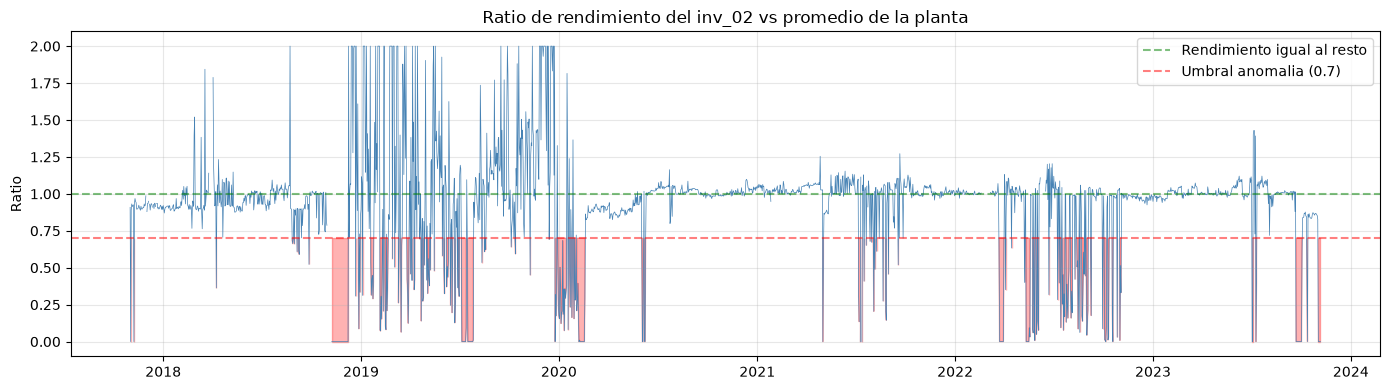

In [81]:
# ver como se comporta el ratio del inversor mas anomalo a lo largo del tiempo
peor_inv = anomalias_series.index[0]
ratio_col = f'ratio_{peor_inv}'

ratio_diario = ratios.set_index('measured_on')[ratio_col].resample('D').mean()
# limitar el ratio para que la grafica se vea bien
ratio_diario = ratio_diario.clip(upper=2.0)

plt.figure(figsize=(14, 4))
plt.plot(ratio_diario.index, ratio_diario.values, linewidth=0.5, color='steelblue')
plt.axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Rendimiento igual al resto')
plt.axhline(umbral, color='red', linestyle='--', alpha=0.5, label=f'Umbral anomalia ({umbral})')
plt.fill_between(ratio_diario.index, ratio_diario.values, umbral, 
                 where=ratio_diario.values < umbral, alpha=0.3, color='red')
plt.title(f'Ratio de rendimiento del {peor_inv} vs promedio de la planta')
plt.ylabel('Ratio')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/ratio_peor_inversor.png', dpi=150, bbox_inches='tight')
plt.show()

Con este enfoque podemos distinguir entre dias malos por clima (donde todos los inversores bajan parejo y el ratio se mantiene cerca de 1) y problemas reales de un inversor especifico (donde su ratio cae mientras los demas siguen normal). Los inversores marcados en rojo son los que mas veces cayeron por debajo del umbral y serian los candidatos a revision de mantenimiento.

---
## Forecasting (series de tiempo)

Para el pronostico uso la potencia total diaria promedio y un modelo ARIMA.

Dias en la serie: 2198


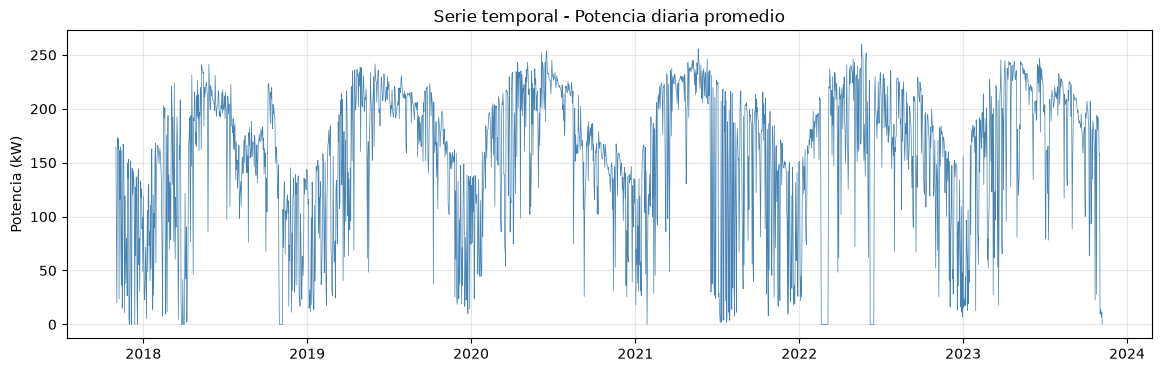

In [82]:
# serie de tiempo diaria
serie_diaria = df_clean.groupby(df_clean['measured_on'].dt.date)['potencia_total'].mean()
serie_diaria.index = pd.to_datetime(serie_diaria.index)
serie_diaria = serie_diaria.asfreq('D', method='ffill')

print(f'Dias en la serie: {len(serie_diaria)}')

plt.figure(figsize=(14, 4))
plt.plot(serie_diaria.index, serie_diaria.values, linewidth=0.5, color='steelblue')
plt.title('Serie temporal - Potencia diaria promedio')
plt.ylabel('Potencia (kW)')
plt.grid(alpha=0.3)
plt.savefig('img/serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

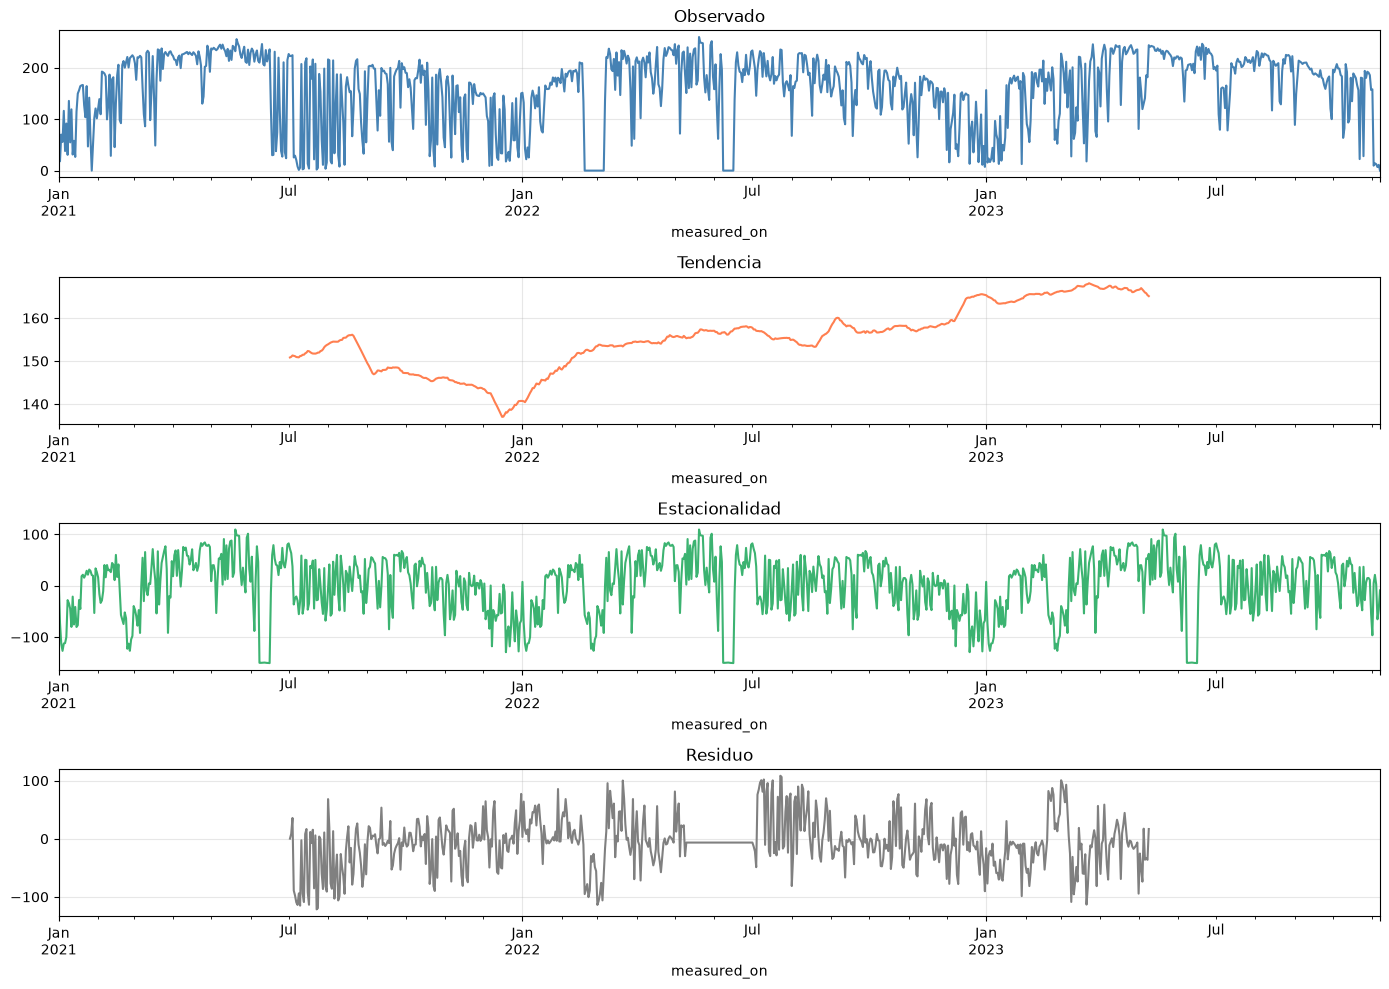

In [83]:
# descomposicion
from statsmodels.tsa.seasonal import seasonal_decompose

serie_reciente = serie_diaria['2021-01-01':]
decomp = seasonal_decompose(serie_reciente, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observado', color='steelblue')
decomp.trend.plot(ax=axes[1], title='Tendencia', color='coral')
decomp.seasonal.plot(ax=axes[2], title='Estacionalidad', color='mediumseagreen')
decomp.resid.plot(ax=axes[3], title='Residuo', color='gray')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/descomposicion.png', dpi=150, bbox_inches='tight')
plt.show()

Se ve una estacionalidad anual clara. La tendencia muestra un ligero incremento a lo largo de los años, lo que podria indicar mejoras en la operacion de la planta o diferencias en las condiciones climaticas entre años.

In [84]:
# ARIMA
from statsmodels.tsa.arima.model import ARIMA

train_ts = serie_reciente[:-30]
test_ts = serie_reciente[-30:]

try:
    modelo_arima = ARIMA(train_ts, order=(5, 1, 2))
    resultado = modelo_arima.fit()
    print(resultado.summary().tables[0])
except:
    modelo_arima = ARIMA(train_ts, order=(2, 1, 1))
    resultado = modelo_arima.fit()
    print(resultado.summary().tables[0])

                               SARIMAX Results                                
Dep. Variable:         potencia_total   No. Observations:                 1011
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -5388.069
Date:                Sat, 04 Jul 2026   AIC                          10792.137
Time:                        23:41:19   BIC                          10831.479
Sample:                    01-01-2021   HQIC                         10807.082
                         - 10-08-2023                                         
Covariance Type:                  opg                                         


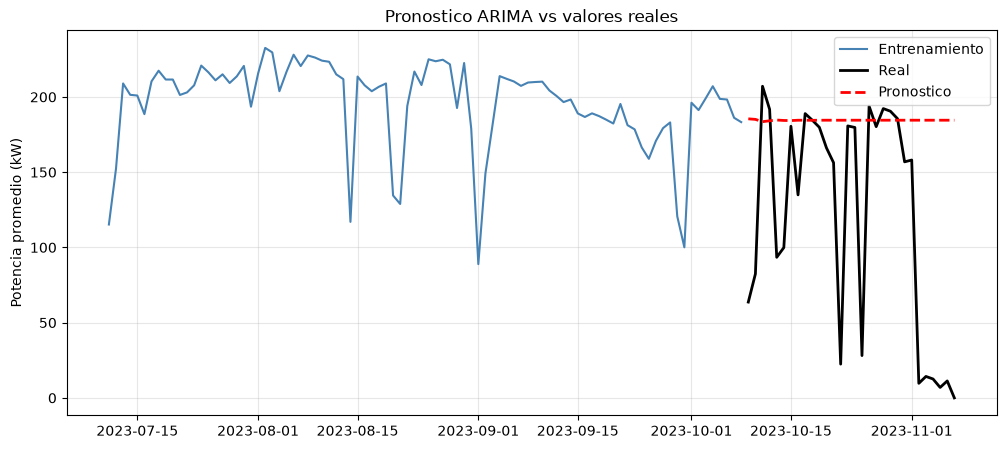

RMSE: 97.0020
MAE:  66.7544


In [85]:
# pronostico
forecast = resultado.forecast(steps=30)

plt.figure(figsize=(12, 5))
plt.plot(train_ts[-90:].index, train_ts[-90:].values, color='steelblue', label='Entrenamiento')
plt.plot(test_ts.index, test_ts.values, color='black', linewidth=2, label='Real')
plt.plot(test_ts.index, forecast.values, color='red', linestyle='--', linewidth=2, label='Pronostico')
plt.title('Pronostico ARIMA vs valores reales')
plt.ylabel('Potencia promedio (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('img/pronostico_arima.png', dpi=150, bbox_inches='tight')
plt.show()

rmse_ts = np.sqrt(mean_squared_error(test_ts, forecast))
mae_ts = mean_absolute_error(test_ts, forecast)
print(f'RMSE: {rmse_ts:.4f}')
print(f'MAE:  {mae_ts:.4f}')

El ARIMA captura la tendencia general pero tiene limitaciones con la variabilidad diaria. Aunque no tenemos datos climaticos directos, en la seccion de anomalias usamos la comparacion entre inversores como proxy: si todos bajan al mismo tiempo es clima, si solo uno baja es falla.

## Evaluacion

In [86]:
print('=' * 60)
print('RESUMEN DE MODELOS')
print('=' * 60)

print('\n1. SUPERVISADO - Prediccion de potencia AC')
print(f'   Reg. Lineal:   R2 train={r2_lr_train:.4f}, R2 test={r2_lr_test:.4f}, RMSE={rmse_lr:.4f}')
print(f'   Random Forest: R2 train={r2_rf_train:.4f}, R2 test={r2_rf_test:.4f}, RMSE={rmse_rf:.4f}')

print(f'\n2. NO SUPERVISADO - Clustering de inversores')
print(f'   K-Means con k=3')
print(f'   Silhouette Score: {sil:.4f}')

print(f'\n3. FORECASTING - Serie de tiempo')
print(f'   ARIMA')
print(f'   RMSE: {rmse_ts:.4f}, MAE: {mae_ts:.4f}')
print('=' * 60)

RESUMEN DE MODELOS

1. SUPERVISADO - Prediccion de potencia AC
   Reg. Lineal:   R2 train=0.0065, R2 test=0.0061, RMSE=10.6956
   Random Forest: R2 train=0.5946, R2 test=0.5915, RMSE=6.8567

2. NO SUPERVISADO - Clustering de inversores
   K-Means con k=3
   Silhouette Score: 0.3897

3. FORECASTING - Serie de tiempo
   ARIMA
   RMSE: 97.0020, MAE: 66.7544


## Discusion

Del analisis se pueden sacar varias cosas:

Los inversores de la planta operan de forma homogenea, todos producen cantidades similares y sus correlaciones son superiores a 0.98. Esto es buena señal para el operador porque significa que no hay inversores con problemas severos.

Para el modelo supervisado se decidio no usar las variables electricas del mismo inversor como features porque la potencia AC es basicamente el producto de corriente por voltaje, lo que hace que predecirla desde esas variables sea redundante. En su lugar se usaron variables temporales (hora y mes) que nos dicen cuanto deberia producir un inversor bajo condiciones normales. El R2 es menor que si usaramos variables electricas, pero el resultado tiene mas valor practico porque permite comparar produccion real vs esperada.

La deteccion de anomalias encontro dias con produccion fuera de lo normal. Estos podrian ser dias con mantenimiento, fallas o condiciones climaticas extremas. El operador podria cruzar esos dias con sus registros.

El pronostico con ARIMA tiene limitaciones porque la produccion solar depende mucho del clima diario, que no esta en el dataset. Aun asi captura el patron estacional general.

## Conclusiones

La planta solar tiene un comportamiento uniforme entre inversores con el patron de generacion esperado para energia solar (campana diaria, variacion estacional).

Se demostro que la potencia se puede estimar desde variables temporales, lo que sirve como referencia para detectar inversores con rendimiento por debajo de lo esperado.

El clustering agrupo a los inversores en perfiles de generacion que sirven como linea base para monitoreo a largo plazo.

El pronostico a corto plazo es factible pero para un sistema mas robusto se necesitaria incorporar datos meteorologicos como radiacion solar y temperatura ambiente.